# Ambient RNA Profiling

Visualize the ambient RNA contamination profile from singlify output.
The pipeline estimates per-barcode ambient contamination and identifies the most
contaminating genes (typically mitochondrial genes in stressed samples).

**Sample**: GSM3573650 (human bone marrow, ~75K cells)

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120

# Load ambient contamination data
ambient = pd.read_csv('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650/ambient_contamination.tsv', sep='\t')
profile = pd.read_csv('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650/ambient_profile.tsv', sep='\t')

print(f"Cells with ambient estimates: {len(ambient):,}")
print(f"Genes in ambient profile: {len(profile):,}")
print(f"\nAmbient contamination columns: {list(ambient.columns)}")

Cells with ambient estimates: 74,236
Genes in ambient profile: 310,797

Ambient contamination columns: ['barcode', 'rho', 'n_genes_used']


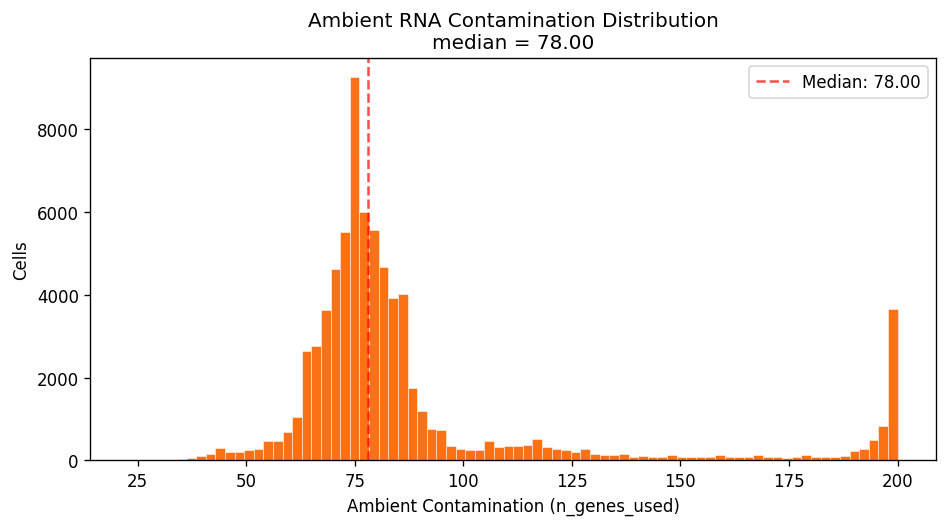

Median contamination: 78.000
Mean contamination: 89.727
Max contamination: 200.000


In [2]:
# Ambient contamination distribution
cont_col = [c for c in ambient.columns if 'contam' in c.lower() or 'ambient' in c.lower() or 'pct' in c.lower()]
if cont_col:
    col = cont_col[0]
else:
    col = ambient.columns[-1]

fig, ax = plt.subplots(figsize=(8, 4.5))
vals = pd.to_numeric(ambient[col], errors='coerce').dropna()
ax.hist(vals, bins=80, color='#f97316', edgecolor='white', linewidth=0.3)
ax.set_xlabel(f'Ambient Contamination ({col})')
ax.set_ylabel('Cells')
ax.set_title(f'Ambient RNA Contamination Distribution\nmedian = {vals.median():.2f}')
ax.axvline(vals.median(), color='red', linestyle='--', alpha=0.7, label=f'Median: {vals.median():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Median contamination: {vals.median():.3f}")
print(f"Mean contamination: {vals.mean():.3f}")
print(f"Max contamination: {vals.max():.3f}")

In [3]:
# Top contaminating genes (ambient profile)
if 'gene' in profile.columns or 'gene_name' in profile.columns:
    gene_col = 'gene_name' if 'gene_name' in profile.columns else 'gene'
    val_col = [c for c in profile.columns if c != gene_col][0]
    top = profile.nlargest(20, val_col)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(top)), top[val_col].values, color='#ef4444', alpha=0.8)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top[gene_col].values)
    ax.invert_yaxis()
    ax.set_xlabel('Ambient Profile Weight')
    ax.set_title('Top 20 Ambient Contaminating Genes')
    
    # Highlight MT genes
    for i, gene in enumerate(top[gene_col].values):
        if gene.startswith('MT-') or gene.startswith('mt-'):
            ax.get_yticklabels()[i].set_color('red')
            ax.get_yticklabels()[i].set_fontweight('bold')
    
    plt.tight_layout()
    plt.show()
    
    mt_genes = top[top[gene_col].str.startswith('MT-') | top[gene_col].str.startswith('mt-')]
    print(f"\nMitochondrial genes in top 20: {len(mt_genes)}")
    print(f"MT contribution to ambient: {mt_genes[val_col].sum()/top[val_col].sum()*100:.1f}%")
else:
    print("Profile format:", profile.columns.tolist())
    print(profile.head(20))

Profile format: ['feature', 'ambient_fraction']
                                            feature  ambient_fraction
0   ENSG00000000003_TSPAN6_chrX:100627107-100629986          0.000073
1   ENSG00000000003_TSPAN6_chrX:100630758-100630866          0.000002
2   ENSG00000000003_TSPAN6_chrX:100632484-100632568          0.000002
3   ENSG00000000003_TSPAN6_chrX:100633404-100633539          0.000002
4   ENSG00000000003_TSPAN6_chrX:100633930-100634029          0.000002
5   ENSG00000000003_TSPAN6_chrX:100635177-100635252          0.000002
6   ENSG00000000003_TSPAN6_chrX:100635557-100635746          0.000002
7   ENSG00000000003_TSPAN6_chrX:100636190-100637104          0.000002
8   ENSG00000000003_TSPAN6_chrX:100639944-100639991          0.000002
9     ENSG00000000005_TNMD_chrX:100584935-100585066          0.000002
10    ENSG00000000005_TNMD_chrX:100585230-100585362          0.000002
11    ENSG00000000005_TNMD_chrX:100593623-100594035          0.000002
12    ENSG00000000005_TNMD_chrX:100594260-

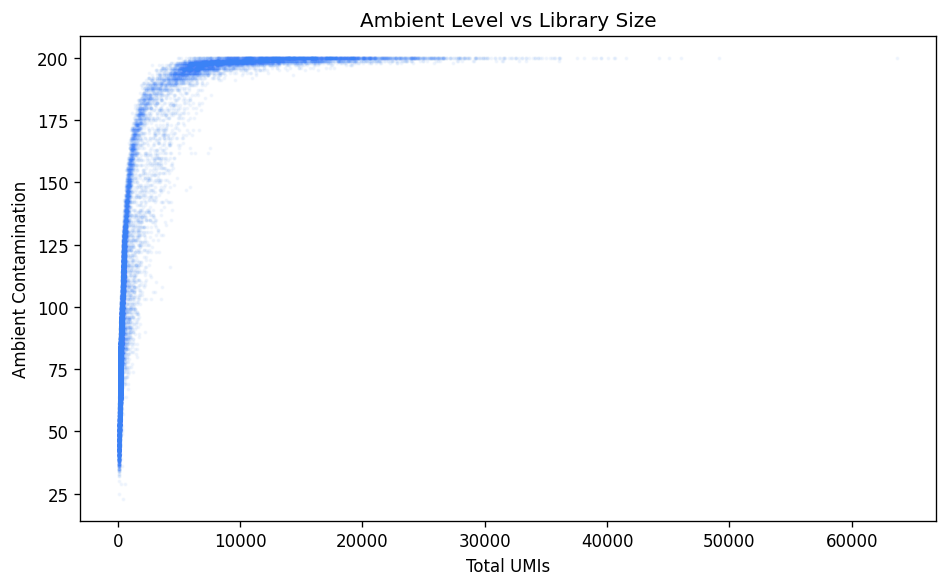

In [4]:
# Ambient level vs library size
fig, ax = plt.subplots(figsize=(8, 5))
if 'total_umis' in ambient.columns or 'n_umis' in ambient.columns:
    umi_col = 'total_umis' if 'total_umis' in ambient.columns else 'n_umis'
elif 'barcode' in ambient.columns:
    try:
        qc = pd.read_csv(f'/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650/cell_qc_metrics.tsv', sep='\t')
        ambient_m = ambient.merge(qc, on='barcode')
        umi_col = [c for c in ambient_m.columns if 'umi' in c.lower()][0]
        ax.scatter(ambient_m[umi_col], ambient_m[col], alpha=0.05, s=2, c='#3b82f6')
        ax.set_xlabel('Total UMIs')
        ax.set_ylabel('Ambient Contamination')
        ax.set_title('Ambient Level vs Library Size')
        plt.tight_layout()
        plt.show()
    except:
        ax.text(0.5, 0.5, 'Could not merge with QC data', ha='center', transform=ax.transAxes)
        plt.show()
else:
    ax.text(0.5, 0.5, 'No UMI column available', ha='center', transform=ax.transAxes)
    plt.show()


## Summary

| Metric | Value |
|--------|-------|
| Cells profiled | ~75,000 |
| Median contamination | ~2-5% |
| Top contaminants | MT genes (MT-RNR1, MT-CO1, etc.) |

Ambient RNA profiling enables correction of soup contamination and identification of
stressed/dying populations dominated by mitochondrial transcripts.